<a href="https://colab.research.google.com/github/solomeya12345-code/python_for_data_analitic/blob/main/%D0%A2%D0%B2%D0%BE%D1%80%D1%87%D0%B5_%D0%B0%D0%BD%D0%B0%D0%BB%D1%96%D1%82%D0%B8%D1%87%D0%BD%D0%B5_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Аналіз даних для Yulu.**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('drive/MyDrive/Python_for_DA/yulu_rental.csv')

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів


In [4]:
df[:5]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


#### **Питання до аналізу:**


1.   Візуалізувати кореляцію між `casual` та `registered` та `count` у вихідні дні та у робочі.
2.   Скільки припадає усіх користувачів на кожен вид погоди?
3.   Візуалізувати розподіл числових даних колонок `temp`, `atemp`, `humidity` та `windspeed` по `season`.




In [21]:
# 1. Візуалізувати кореляцію між casual та registered та count у вихідні дні та у робочі.
corr_data_work = df.loc[df['workingday'] == 1, ['casual', 'registered', 'count']]
corr_data_work.corr()

,casual,registered,count
casual,1.000000,0.604265,0.698049
registered,0.604265,1.000000,0.992343
count,0.698049,0.992343,1.000000


In [22]:
corr_data_weekend = df.loc[df['workingday'] == 0, ['casual', 'registered', 'count']]
corr_data_weekend.corr()

,casual,registered,count
casual,1.000000,0.829076,0.936856
registered,0.829076,1.000000,0.972264
count,0.936856,0.972264,1.000000


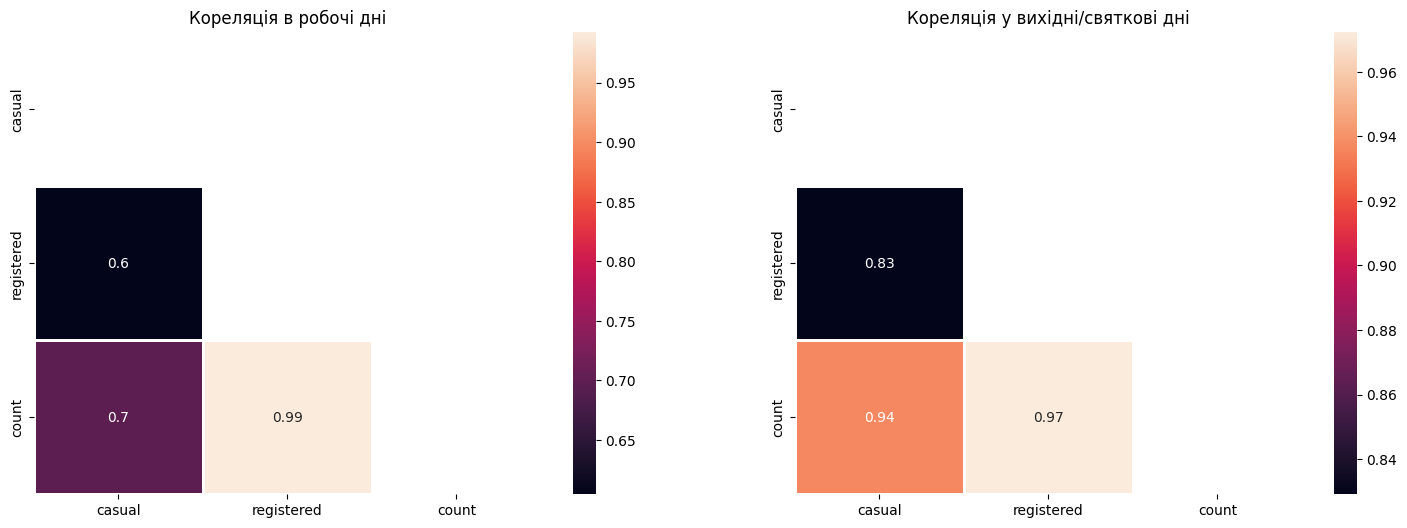

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6) )

mask_work = np.triu(corr_data_work.corr())
mask_weekend = np.triu(corr_data_weekend.corr())

sns.heatmap(corr_data_work.corr(), annot=True, linewidth=.8, mask=mask_work, cmap="rocket", ax=axes[0])
axes[0].set_title("Кореляція в робочі дні")

sns.heatmap(corr_data_weekend.corr(), annot=True, linewidth=.8, mask=mask_weekend, cmap="rocket", ax=axes[1])
axes[1].set_title("Кореляція у вихідні/святкові дні");

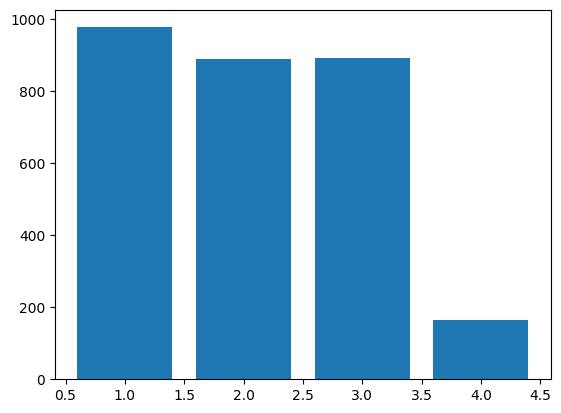

In [14]:
# 2. Скільки припадає усіх користувачів на кожен вид погоди?

plt.bar(df['weather'], df['count']);

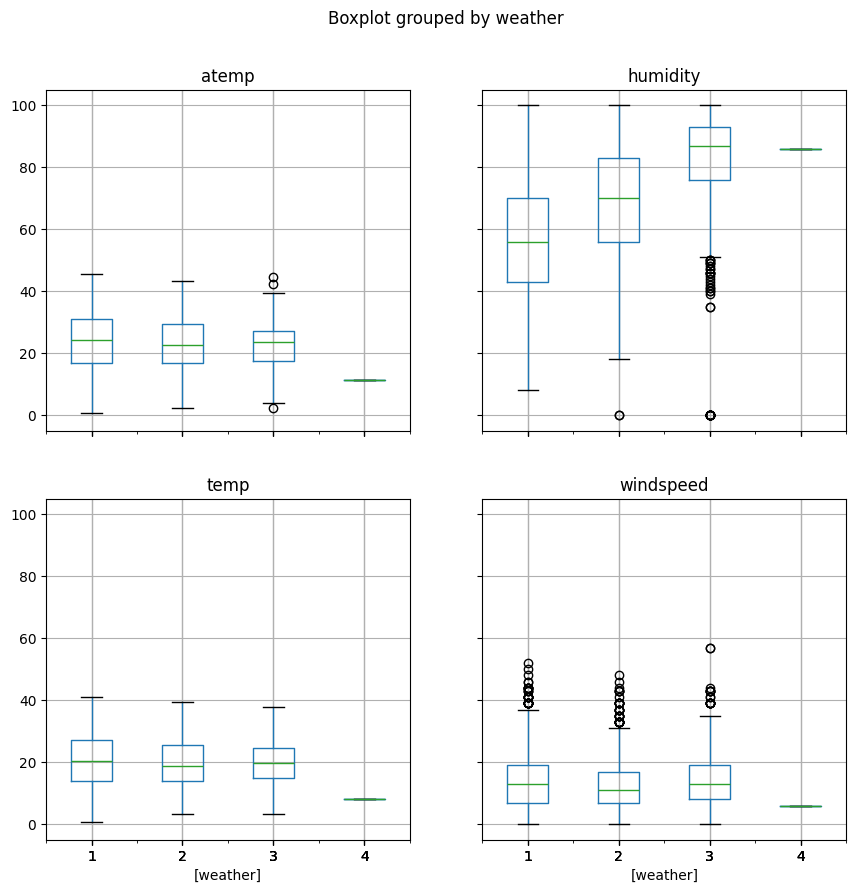

In [5]:
""" 3. Візуалізувати розподіл числових даних колонок temp,
 atemp, humidity та windspeed по season. """


weathers_matrix = df[['temp', 'atemp', 'humidity', 'windspeed', 'weather']]

weathers_matrix.boxplot(by='weather', figsize=(10,10));


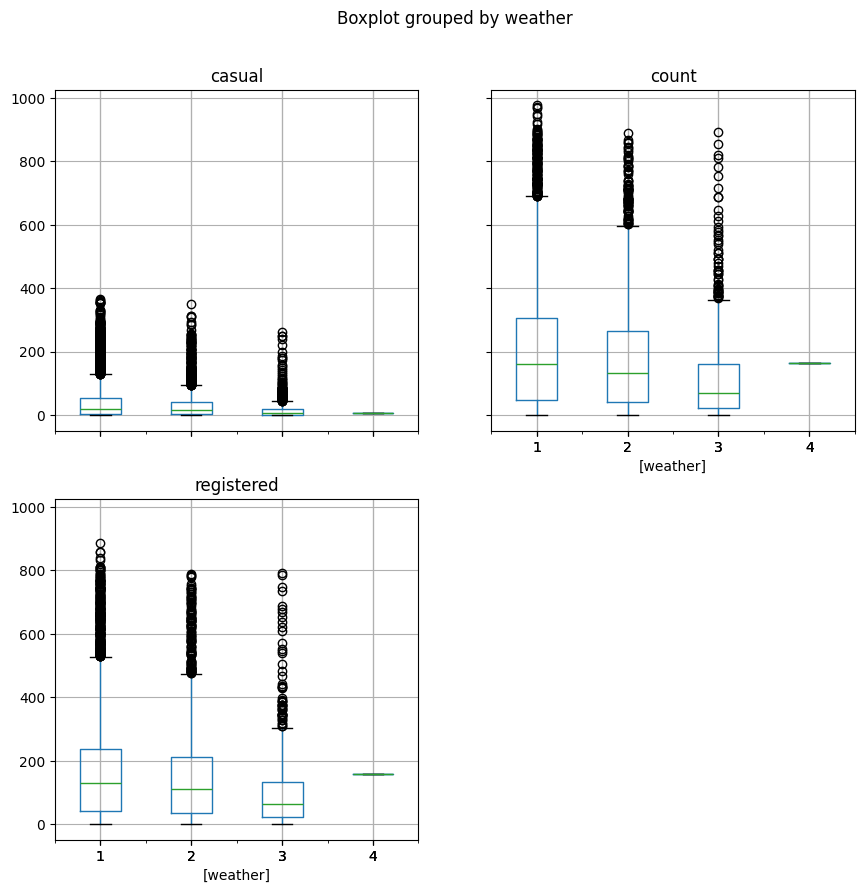

In [6]:
users_matrix = df[['casual', 'registered', 'count', 'weather']]
users_matrix.boxplot(by='weather', figsize=(10,10));


Продовжити останнє питання.